<a href="https://colab.research.google.com/github/austinjstf/dotCon/blob/main/dotCon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Building balanced dataset...
Target per class : 800 images
---------------------------------------------
  Class infant         | folders: 001-003    | 800 images
  Class child          | folders: 004-012    | 800 images
  Class teen           | folders: 013-019    | 800 images
  Class young_adult    | folders: 020-035    | 800 images
  Class middle_age     | folders: 036-055    | 800 images
  Class senior         | folders: 056-110    | 800 images
---------------------------------------------
  TOTAL          | 4800 images across 6 classes

Dataset ready.

Loading dataset...
Found 4800 files belonging to 6 classes.
Using 3840 files for training.
Found 4800 files belonging to 6 classes.
Using 960 files for validation.

Classes (6): ['child', 'infant',

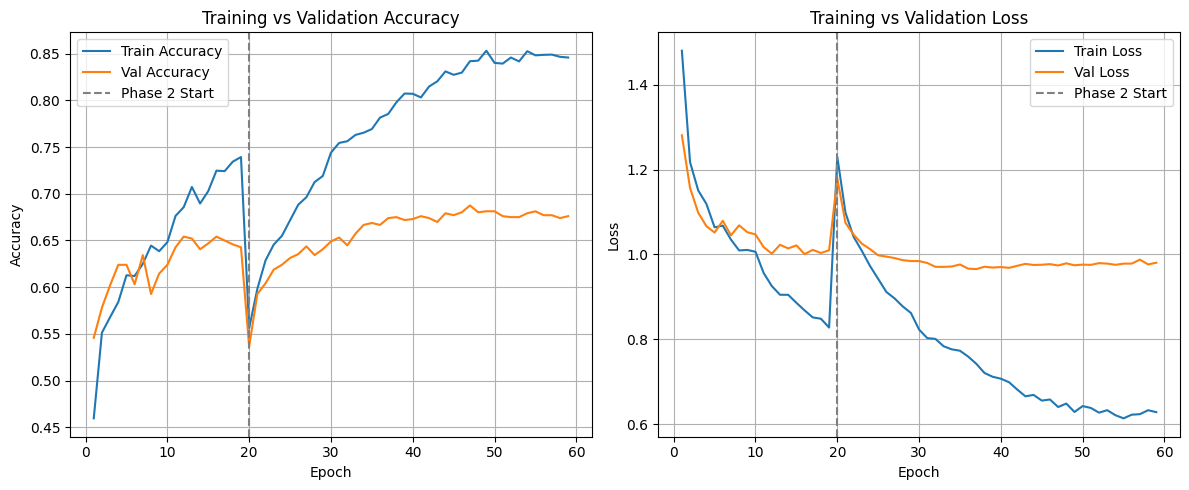

Plot saved to: /content/drive/MyDrive/training_accuracy.png

TRAINING COMPLETE
Classes        : ['child', 'infant', 'middle_age', 'senior', 'teen', 'young_adult']
Phase 1 Acc    : 65.42%
Final Acc      : 68.75%
Model saved to : /content/drive/MyDrive/model_age_demo.keras
Plot saved to  : /content/drive/MyDrive/training_accuracy.png

Next: Download model_age_demo.keras and run demo.py locally.


In [3]:
# ============================================================
#  Age Classification - Training Script v4
#  Run this in Google Colab with a T4 GPU
#  Austin Steffes - dotCon Demo
#
#  Changes from v3 (goal: push past 70% val accuracy):
#    1. Phase 2 epochs 50 -> 80. The v3 run was STILL improving
#       at the epoch cap (best val was the final epoch), so it
#       ran out of road rather than converging. More epochs is
#       the highest-probability lever.
#    2. Phase 2 LR 1e-5 -> 3e-5. The v3 fine-tune climbed slowly
#       and monotonically with no overfitting blowup, meaning
#       there was headroom to converge faster within budget.
#
#  Carried over from v3 (vs original v2):
#    - Mixup removed (was capping train accuracy at ~0.55).
#    - Lighter augmentation (flip + light rotation + light zoom).
#    - Eased regularizers (dropout 0.4/0.3, label_smoothing 0.05).
#
#  v3 result: 67.4% final val (up from 62.71% in v2).
# ============================================================

# -- STEP 1: Mount Google Drive ------------------------------
from google.colab import drive
drive.mount('/content/drive')

# -- STEP 2: Imports -----------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# -- STEP 3: Config ------------------------------------------
DATASET_DIR  = "/content/drive/MyDrive/dotCon/A4_dataset_ALL"
MODEL_PATH   = "/content/drive/MyDrive/model_age_demo.keras"
PLOT_PATH    = "/content/drive/MyDrive/training_accuracy.png"

IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

TARGET_PER_CLASS = 800

# -- CLASS CONFIG (6 coarse brackets) ------------------------
CLASS_CONFIG = [
    {
        "label":   "infant",
        "sources": ["001", "002", "003"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "child",
        "sources": ["004", "005", "006", "007", "008", "009", "010", "011", "012"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "teen",
        "sources": ["013", "014", "015", "016", "017", "018", "019"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "young_adult",
        "sources": ["020", "021", "022", "023", "024", "025", "026", "027", "028", "029", "030", "031", "032", "033", "034", "035"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "middle_age",
        "sources": ["036", "037", "038", "039", "040", "041", "042", "043", "044", "045", "046", "047", "048", "049", "050", "051", "052", "053", "054", "055"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "senior",
        "sources": ["056", "057", "058", "059", "060", "061", "062", "063", "064", "065", "066", "067", "068", "069", "070",
                    "075", "080", "085", "090", "095", "100", "105", "110"],
        "cap":     TARGET_PER_CLASS,
    },
]

NUM_CLASSES = len(CLASS_CONFIG)

# -- STEP 4: Build Balanced Dataset --------------------------
import shutil
import random

random.seed(SEED)

FILTERED_DIR = "/content/dataset_filtered"

if os.path.exists(FILTERED_DIR):
    shutil.rmtree(FILTERED_DIR)
os.makedirs(FILTERED_DIR)

print("\nBuilding balanced dataset...")
print(f"Target per class : {TARGET_PER_CLASS} images")
print("-" * 45)

total_images = 0
for cfg in CLASS_CONFIG:
    label   = cfg["label"]
    sources = cfg["sources"]
    cap     = cfg["cap"]

    dst = os.path.join(FILTERED_DIR, label)
    os.makedirs(dst, exist_ok=True)

    all_files = []
    for src_folder in sources:
        src_path = os.path.join(DATASET_DIR, src_folder)
        if os.path.exists(src_path):
            files = [
                os.path.join(src_path, f)
                for f in os.listdir(src_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_files.extend(files)

    random.shuffle(all_files)
    selected = all_files[:cap] if cap else all_files

    for i, src_file in enumerate(selected):
        ext = os.path.splitext(src_file)[1]
        dst_file = os.path.join(dst, f"{label}_{i:04d}{ext}")
        shutil.copy2(src_file, dst_file)

    count = len(selected)
    total_images += count
    src_str = f"{sources[0]}-{sources[-1]}"
    print(f"  Class {label:<14} | folders: {src_str:<10} | {count:>3} images")

print("-" * 45)
print(f"  TOTAL          | {total_images} images across {NUM_CLASSES} classes")
print("\nDataset ready.")

# -- STEP 5: Data Augmentation -------------------------------
# Lighter than v2. Faces have a canonical orientation, so we
# keep horizontal flip + small rotation + small zoom and drop
# translation / brightness / contrast.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

# -- STEP 6: Load Data ---------------------------------------
print("\nLoading dataset...")

common_args = dict(
    directory=FILTERED_DIR,
    validation_split=0.2,
    label_mode="categorical",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

training_set = image_dataset_from_directory(subset="training",   **common_args)
test_set     = image_dataset_from_directory(subset="validation", **common_args)

class_names = training_set.class_names
print(f"\nClasses ({len(class_names)}): {class_names}")
print(f"Training batches : {len(training_set)}")
print(f"Validation batches: {len(test_set)}")

AUTOTUNE = tf.data.AUTOTUNE

# No Mixup. Just prefetch both sets.
training_set = training_set.prefetch(buffer_size=AUTOTUNE)
test_set     = test_set.prefetch(buffer_size=AUTOTUNE)

# -- STEP 7: Build Model -------------------------------------
print("\nBuilding model...")

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)           # eased from 0.5
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)           # eased from 0.4
output_layer = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.05),   # eased from 0.1
    metrics=["accuracy"]
)

print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# -- STEP 8: Callbacks ---------------------------------------
callbacks_phase1 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# -- STEP 9: Phase 1 - Frozen Base ---------------------------
print("\n" + "="*50)
print("PHASE 1: Training top layers (base frozen)")
print("="*50)

history1 = model.fit(
    training_set,
    epochs=30,
    validation_data=test_set,
    callbacks=callbacks_phase1,
    verbose=2
)

score1 = model.evaluate(test_set, verbose=2)
print(f"\nPhase 1 - Val Accuracy: {round(score1[1] * 100, 2)}%")

# -- STEP 10: Phase 2 - Fine-Tuning --------------------------
print("\n" + "="*50)
print("PHASE 2: Fine-tuning (unfreezing top 100 base layers)")
print("="*50)

unfreeze_from = len(base_model.layers) - 100
for i, layer in enumerate(base_model.layers):
    layer.trainable = i >= unfreeze_from

print(f"Total base layers : {len(base_model.layers)}")
print(f"Unfreezing from   : layer {unfreeze_from} onward")

model.compile(
    optimizer=Adam(learning_rate=3e-5),   # bumped from 1e-5: v3 never plateaued, had headroom
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

print(f"Trainable params after unfreeze: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

callbacks_phase2 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    )
]

history2 = model.fit(
    training_set,
    epochs=80,                            # bumped from 50: v3 was still climbing at the cap
    validation_data=test_set,
    callbacks=callbacks_phase2,
    verbose=2
)

score2 = model.evaluate(test_set, verbose=2)
print(f"\nPhase 2 - Final Val Accuracy: {round(score2[1] * 100, 2)}%")

# -- STEP 11: Save Final Model -------------------------------
model.save(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")

# -- STEP 12: Plot Training History --------------------------
acc1  = history1.history["accuracy"]
acc2  = history2.history["accuracy"]
val1  = history1.history["val_accuracy"]
val2  = history2.history["val_accuracy"]

all_acc     = acc1 + acc2
all_val_acc = val1 + val2
epochs_range = range(1, len(all_acc) + 1)
phase2_start = len(acc1) + 1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_acc,     label="Train Accuracy")
plt.plot(epochs_range, all_val_acc, label="Val Accuracy")
plt.axvline(x=phase2_start, color="gray", linestyle="--", label="Phase 2 Start")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

loss1     = history1.history["loss"]
loss2     = history2.history["loss"]
val_loss1 = history1.history["val_loss"]
val_loss2 = history2.history["val_loss"]

all_loss     = loss1 + loss2
all_val_loss = val_loss1 + val_loss2

plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_loss,     label="Train Loss")
plt.plot(epochs_range, all_val_loss, label="Val Loss")
plt.axvline(x=phase2_start, color="gray", linestyle="--", label="Phase 2 Start")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(PLOT_PATH)
plt.show()
print(f"Plot saved to: {PLOT_PATH}")

# -- STEP 13: Summary ----------------------------------------
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Classes        : {class_names}")
print(f"Phase 1 Acc    : {round(score1[1] * 100, 2)}%")
print(f"Final Acc      : {round(score2[1] * 100, 2)}%")
print(f"Model saved to : {MODEL_PATH}")
print(f"Plot saved to  : {PLOT_PATH}")
print("\nNext: Download model_age_demo.keras and run demo.py locally.")


PER-CLASS REPORT
              precision    recall  f1-score   support

       child      0.716     0.701     0.709       144
      infant      0.962     0.882     0.920       144
  middle_age      0.573     0.589     0.581       180
      senior      0.725     0.778     0.751       176
        teen      0.586     0.642     0.613       159
 young_adult      0.626     0.554     0.588       157

    accuracy                          0.688       960
   macro avg      0.698     0.691     0.694       960
weighted avg      0.692     0.688     0.688       960



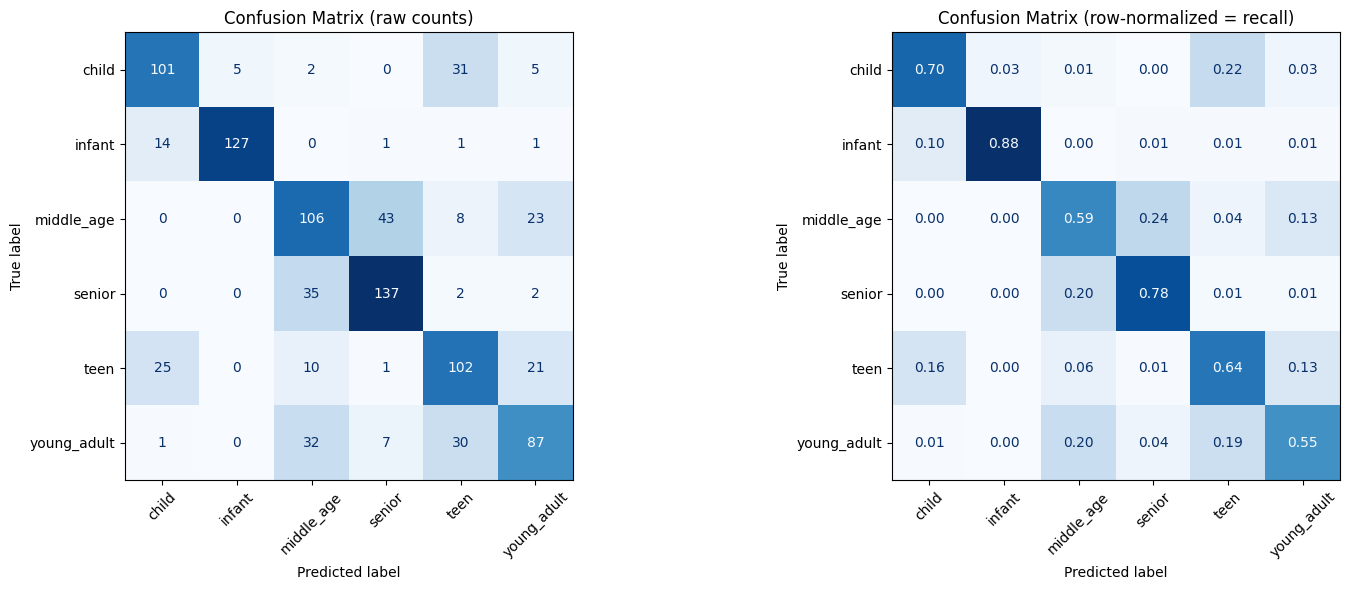


Saved to: /content/drive/MyDrive/confusion_matrix.png

Most-confused pair: 'middle_age' predicted as 'senior' (23.9% of 'middle_age' samples)


In [4]:
# ============================================================
#  Confusion Matrix + Per-Class Report
#  Run as a SEPARATE Colab cell AFTER training finishes.
#  Reuses the in-memory `test_set` and `class_names` from the
#  training run, plus the saved model on Drive.
#
#  What to look for:
#    - Off-diagonal mass on ADJACENT brackets (teen<->young_adult,
#      middle_age<->senior) = expected fuzzy-label error, near the
#      honest ceiling for 6 brackets. Not really fixable by tuning.
#    - One row/class with low recall = that class is collapsing;
#      it likely needs more/cleaner data. THIS is fixable.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

MODEL_PATH = "/content/drive/MyDrive/model_age_demo.keras"

# Load the best saved model (restore_best_weights already kept the
# best in memory, but loading from disk guarantees we score the
# exact checkpoint that was saved).
model = tf.keras.models.load_model(MODEL_PATH)

# Collect predictions over the whole validation set.
# IMPORTANT: do NOT shuffle here, and pull labels straight from the
# same batches we predict on, so y_true and y_pred stay aligned.
y_true = []
y_pred = []

for images, labels in test_set:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# class_names comes from the training run (training_set.class_names).
# If running in a fresh session, hardcode it to match the printed order:
# class_names = ['child', 'infant', 'middle_age', 'senior', 'teen', 'young_adult']

print("\n" + "="*55)
print("PER-CLASS REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)

# Row-normalized version (recall per class) is easier to read than raw counts
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Confusion Matrix (raw counts)")

ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f"
)
axes[1].set_title("Confusion Matrix (row-normalized = recall)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=120)
plt.show()
print("\nSaved to: /content/drive/MyDrive/confusion_matrix.png")

# Quick automatic read: flag the worst-confused pair
np.fill_diagonal(cm_norm, 0)
i, j = np.unravel_index(np.argmax(cm_norm), cm_norm.shape)
print(f"\nMost-confused pair: '{class_names[i]}' predicted as "
      f"'{class_names[j]}' ({cm_norm[i, j]*100:.1f}% of '{class_names[i]}' samples)")